In [145]:
# 공통 설정 (다른 셀을 실행하기 전에 이 셀을 먼저 실행하세요)
%load_ext autoreload
%autoreload 2

import os

miktex_bin = r"C:\Users\hbkim\AppData\Local\Programs\MiKTeX\miktex\bin\x64"
if miktex_bin not in os.environ["PATH"]:
    os.environ["PATH"] = miktex_bin + os.pathsep + os.environ["PATH"]

from manim import *
from reactive_manim import *
from manim.utils.ipython_magic import ManimMagic

from module.mobjects import write_text, axes

get_ipython().register_magics(ManimMagic)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## write_text 테스트

In [146]:
%%manim -ql -v WARNING WriteTextTest
class WriteTextTest(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        text = write_text("안녕하세요", color=BLACK)
        self.play(Write(text))
        self.wait(1)

Manim Community v0.21.0

## axes 테스트

In [147]:
%%manim -ql -v WARNING AxesTest
class AxesTest(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        ax = axes(x_range=[-4, 4, 1], y_range=[-1, 4, 1])
        graph = ax.plot(lambda x: x ** 2, color=BLUE)
        self.play(FadeIn(ax))
        self.play(Create(graph))
        self.wait(1)

Manim Community v0.21.0

## 카메라로 여러 구역 순회하기

In [148]:
%%manim -ql -v WARNING CampusTour
class CampusTour(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE

        # 여러 구역(존)을 화면 곳곳에 배치. 각 존은 사각형 + 이름표로 구성
        zone_data = [
            ("정문", LEFT * 6 + UP * 3, BLUE),
            ("도서관", RIGHT * 6 + UP * 3, GREEN),
            ("운동장", LEFT * 6 + DOWN * 3, ORANGE),
            ("강의동", RIGHT * 6 + DOWN * 3, PURPLE),
            ("중앙광장", ORIGIN, RED),
        ]

        zones = VGroup()
        for name, position, color in zone_data:
            box = Rectangle(width=3, height=2, color=color, fill_opacity=0.2)
            label = Text(name, font="Malgun Gothic", color=BLACK, font_size=32)
            zone = VGroup(box, label).move_to(position)
            zones.add(zone)

        self.add(zones)
        self.camera.frame.scale(2.2).move_to(ORIGIN)  # 처음엔 전체 구역이 다 보이도록 줌아웃
        self.wait(0.5)

        # 각 구역을 순서대로 확대해서 순회
        for zone in zones:
            self.play(self.camera.frame.animate.move_to(zone).scale(1 / 2.2), run_time=1.2)
            self.wait(0.5)
            self.play(self.camera.frame.animate.scale(2.2), run_time=0.8)  # 다음 이동 전 다시 줌아웃

        # 마지막에 전체 구역이 보이도록 원점으로 복귀
        self.play(self.camera.frame.animate.move_to(ORIGIN), run_time=1.2)
        self.wait(1)

Manim Community v0.21.0

## 정지 프레임(이미지)으로 빠르게 미리보기

Manim Community v0.21.0

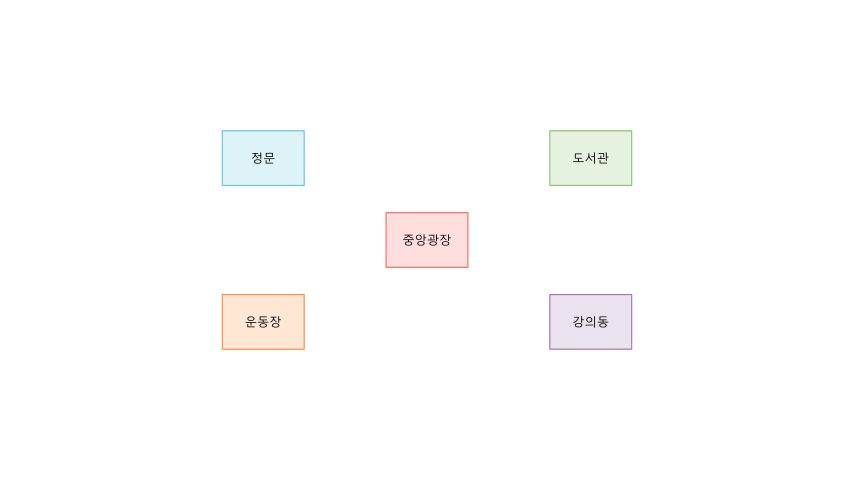

In [149]:
%%manim -s -ql -v WARNING CampusTourPreview
class CampusTourPreview(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE

        zone_data = [
            ("정문", LEFT * 6 + UP * 3, BLUE),
            ("도서관", RIGHT * 6 + UP * 3, GREEN),
            ("운동장", LEFT * 6 + DOWN * 3, ORANGE),
            ("강의동", RIGHT * 6 + DOWN * 3, PURPLE),
            ("중앙광장", ORIGIN, RED),
        ]

        zones = VGroup()
        for name, position, color in zone_data:
            box = Rectangle(width=3, height=2, color=color, fill_opacity=0.2)
            label = Text(name, font="Malgun Gothic", color=BLACK, font_size=32)
            zone = VGroup(box, label).move_to(position)
            zones.add(zone)

        # -s(save_last_frame)를 쓰면 재생 없이 이 상태 그대로 PNG 한 장만 저장/출력됨
        self.camera.frame.scale(2.2).move_to(ORIGIN)
        self.add(zones)

## A053신명조 폰트 테스트

Manim Community v0.21.0

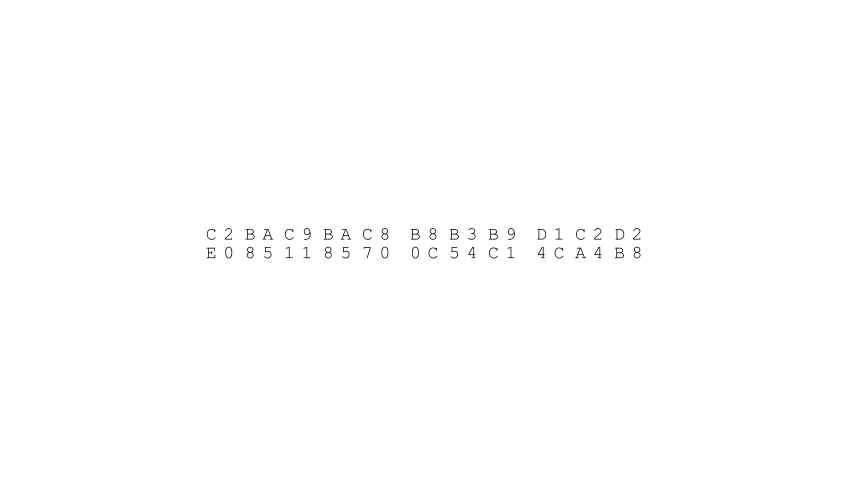

In [150]:
%%manim -s -ql -v WARNING ShinmyeongFontTest
class ShinmyeongFontTest(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        text = Text("신명중명조 렌더링 테스트", font="A053신명조", color=BLACK, font_size=48)
        self.add(text)

In [151]:
%%manim -s -ql -v WARNING KoreanFontCompare
class KoreanFontCompare(Scene):
            solution = MathTex(
                r"2^{\frac{3}{2}}",
                r"\times",
                r"4^{-\frac{1}{2}}"
            )
        self.camera.background_color = WHITE

            solution_center = solution.get_center()
            self.play(
                self.camera.frame.animate.move_to(solution_center),
                run_time=1.5,
            )
            self.wait(0.5)
        noto = Text("명조체 렌더링 테스트 (Noto Serif KR)", font="Noto Serif KR", color=BLACK, font_size=36)
        batang = Text("명조체 렌더링 테스트 (바탕)", font="Batang", color=BLACK, font_size=36)

        group = VGroup(noto, batang).arrange(DOWN, buff=0.8)
        self.add(group)

IndentationError: unindent does not match any outer indentation level (<string>, line 7)

## 문제 7번을 바탕체로 렌더링

Manim Community v0.21.0

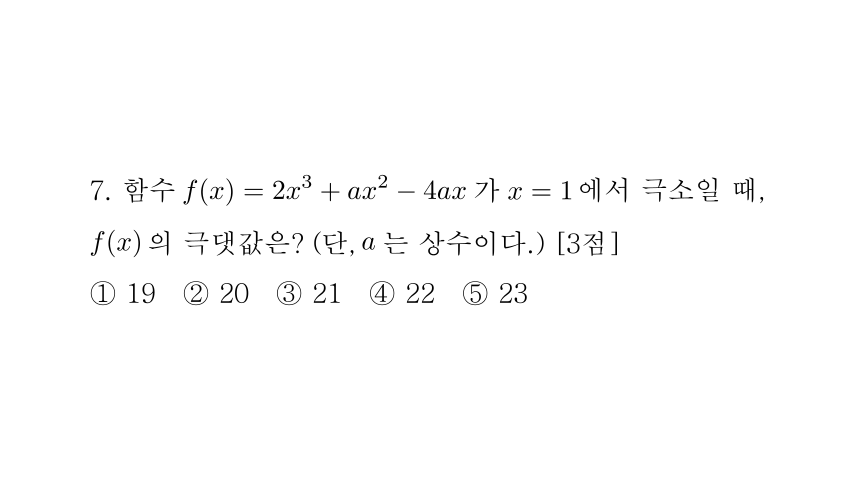

In [ ]:
%%manim -s -ql -v WARNING Problem7Batang
class Problem7Batang(Scene):
    def construct(self):
        self.camera.background_color = WHITE

        def batang(text):
            return Text(text, font="Batang", color=BLACK, font_size=32)

        line1 = VGroup(
            batang("7. 함수"),
            MathTex(r"f(x)=2x^3+ax^2-4ax", color=BLACK, font_size=44),
            batang("가"),
            MathTex(r"x=1", color=BLACK, font_size=44),
            batang("에서 극소일 때,"),
        ).arrange(RIGHT, buff=0.15)

        line2 = VGroup(
            MathTex(r"f(x)", color=BLACK, font_size=44),
            batang("의 극댓값은? (단,"),
            MathTex(r"a", color=BLACK, font_size=44),
            batang("는 상수이다.) [3점]"),
        ).arrange(RIGHT, buff=0.15)

        choices = batang("① 19   ② 20   ③ 21   ④ 22   ⑤ 23")

        group = VGroup(line1, line2, choices).arrange(DOWN, aligned_edge=LEFT, buff=0.4)
        self.add(group)

## pdf_tools로 문제 7번 원본 이미지 크롭

In [ ]:
%%manim -ql -v WARNING Problem7Solve
from study.pdf_tools import pdf_problem_image
from manim.mobject.text.tex_mobject import MathTex as ManimMathTex
import copy


def place_in_region(mobject, left, top, width):
    if mobject.width > width:
        mobject.scale_to_fit_width(width)
    mobject.move_to([left + mobject.width / 2, top - mobject.height / 2, 0])
    return mobject


def animate_scale_and_move_to_top_left(frame, scale, top_left):
    scaled_width = frame.width * scale
    scaled_height = frame.height * scale
    top_left = np.array(top_left, dtype=float)
    center = top_left + RIGHT * scaled_width / 2 + DOWN * scaled_height / 2
    return frame.animate.scale(scale).move_to(center)


class Problem7Solve(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=20)

        margin = 0.4
        content_width = config.frame_width - 2 * margin
        content_height = config.frame_height - 2 * margin
        content_left = -config.frame_width / 2 + margin
        content_right = config.frame_width / 2 - margin
        content_top = config.frame_height / 2 - margin

        boundary_x = config.frame_width * -0.1
        problem_width = boundary_x - content_left - margin
        problem_x = content_left
        solution_width = content_right - boundary_x - margin
        solution_x = boundary_x + margin

        divider = Line(
            start=[boundary_x, content_top, 0],
            end=[boundary_x, content_top - content_height, 0],
            color=BLACK,
            stroke_width=2,
        )

        problem_image = pdf_problem_image(
            "mathB_1_mun_ZM4M1F58.pdf",
            problem_number=1,
        )
        place_in_region(problem_image, problem_x, content_top, problem_width)
        self.add(divider, problem_image)

        self.play(
            animate_scale_and_move_to_top_left(
                self.camera.frame,
                scale=0.2,
                top_left=[boundary_x, config.frame_height / 2, 0],
            ),
            run_time=1.5,
        )
        self.camera.frame.save_state()

        
        sol1 = MathTex("2", r"^{\frac{3}{2}}", r"\times", "4", r"^{-\frac{1}{2}}")
        sol2 = MathTex("2", r"^{\frac{3}{2}}", r"\times", "(", "2", "^2", ")", r"^{-\frac{1}{2}}")
        sol3 = MathTex("2", r"^{\frac{3}{2}}", r"\times", "2", r"^{2", r"\times", r"-(\frac{1}{2})}")
        place_in_region(sol1, solution_x, content_top, solution_width)
        place_in_region(sol2, solution_x, content_top, solution_width)
        place_in_region(sol3, solution_x, content_top, solution_width)
        self.add(sol1)
        self.wait(0.5)
        
        self.play(TransformMatchingTex(sol1, sol2))
        self.wait(1)
        self.play(TransformMatchingTex(sol2, sol3))
        self.wait(1)
        

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING Problem7SolveFinal

class Problem7SolveFinal(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=50)

        t0, t1, t2, t3, t4, t5 = MathTex("=", "2", Fraction(3, 2), r"\times", "4", ["-", Fraction(1, 2)])
        sol1 = MathTex(Term(t1, t2), t3, Term(t4, t5))
        sol2 = MathTex(t0, Term(t1, t2), t3, Term(t4, t5)); sol2[3].base.set_tex_string(r"\left(2^2\right)")
        sol2_1 = sol2.copy(); sol2_1[3].base = MathTex(Paren(Term(2, 2)))
        sol3 = MathTex(t0, Term(t1, t2), t3, Term(sol2_1[3].base[0].inner.base, [sol2_1[3].base[0].inner.exponent, r"\times", Paren(t5)]))
        sol3_1 = sol3.copy(); sol3_1[3].exponent = MathString(sol3[3].exponent.get_tex_string(), color=BLACK)
        sol4 = sol3_1.copy(); sol4[3].exponent.set_tex_string("-1")
        sol4_1 = sol4.copy(); sol4_1[3].base = t1
        sol5 = MathTex(t0, Term(t1, [t2, sol4_1[3].exponent]))
        sol5_1 = sol5.copy(); sol5_1[1].exponent = MathString(sol5[1].exponent.get_tex_string(), color=BLACK)
        sol6 = sol5_1.copy(); sol6[1].exponent.set_tex_string(r"\frac{1}{2}")
        group = VGroup(sol1, sol2, sol3, sol4, sol5, sol6).arrange(DOWN, aligned_edge=LEFT, buff=MED_LARGE_BUFF)
        
        self.add(sol1)
        self.play(
            TransformInStages.from_copy(sol1, sol2),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.add(sol2_1.move_to(sol2.get_center()))
        self.remove(sol2)
        self.play(
            TransformInStages.from_copy(sol2_1, sol3),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.add(sol3_1.move_to(sol3.get_center()))
        self.remove(sol3)
        self.play(
            TransformInStages.from_copy(sol3_1, sol4),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.add(sol4_1.move_to(sol4.get_center()))
        self.remove(sol4)
        self.play(
            TransformInStages.from_copy(sol4_1, sol5),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.add(sol5_1.move_to(sol5.get_center()))
        self.remove(sol5)
        self.play(
            TransformInStages.from_copy(sol5_1, sol6),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.wait(1)

Manim Community v0.21.0

In [ ]:
from reactive_manim import DynamicMobject

def change(old, new):
    # 하나 또는 여러 원본 객체
    originals = list(old) if isinstance(old, (list, tuple)) else [old]

    if not originals:
        raise ValueError("원본 객체가 필요합니다.")

    color = originals[0].get_color()

    if isinstance(new, DynamicMobject):
        result = new.clone()
    else:
        result = MathString(str(new), color=color)

    # Term의 밑·지수, Paren 내부까지 원본 색 적용
    result.set_color(color, family=True)

    sources = [
        part
        for original in originals
        for part in original.get_dynamic_family()
        if part.has_direct_points()
    ]

    targets = [
        part for part in result.get_dynamic_family()
        if part.has_direct_points()
    ]

    if not sources or not targets:
        raise ValueError("변환할 글자나 선이 없습니다.")

    for i, source in enumerate(sources):
        j = min(i * len(targets) // len(sources), len(targets) - 1)
        source.target_id = targets[j].id

    for i, target in enumerate(targets):
        j = min(i * len(sources) // len(targets), len(sources) - 1)
        target.source_id = sources[j].id

    return result

In [157]:
%%manim -ql -v WARNING TestScene

class TestScene(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE\
        
        t0, t1, t2, t3, t4, t5 = MathTex("=", "2", Fraction(3, 2), r"\times", "4", ["-", Fraction(1, 2)])
        sol1 = MathTex(Term(t1, t2), t3, Term(t4, t5))
        sol2 = MathTex(t0, Term(t1, t2), t3, Term(t4, t5)); sol2[3].base = change(sol1[2].base, Paren(Term(2, 2)))
        sol3 = MathTex(t0, Term(t1, t2), t3, Term(sol2[3].base.inner.base, [sol2[3].base.inner.exponent, r"\times", Paren(t5)]))
        sol4 = sol3.copy(); sol4[3].exponent = change(sol3[3].exponent, -1)
        sol5 = MathTex(t0, Term(change([sol4[1].base, sol4[3].base], 2), [sol4[1].exponent, sol4[3].exponent]))
        sol6 = sol5.copy(); sol6[1].exponent = change(sol5[1].exponent, r"\frac{1}{2}")
        group = VGroup(sol1, sol2, sol3, sol4, sol5, sol6).arrange(DOWN, aligned_edge=LEFT, buff=MED_LARGE_BUFF)
        
        self.add(sol1)
        self.play(
            TransformInStages.from_copy(sol1, sol2),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.play(
            TransformInStages.from_copy(sol2, sol3),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.play(
            TransformInStages.from_copy(sol3, sol4),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.play(
            TransformInStages.from_copy(sol4, sol5),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.play(
            TransformInStages.from_copy(sol5, sol6),
            self.camera.frame.animate.shift(MED_LARGE_BUFF * DOWN),
            lag_ratio=0.5
        )
        self.wait(1)
        self.play(self.camera.frame.animate.scale(1.5).move_to(group.get_center()))
        self.wait(1)
        


Manim Community v0.21.0

## 풀이 영역에서 식 정리 애니메이션

Manim Community v0.21.0

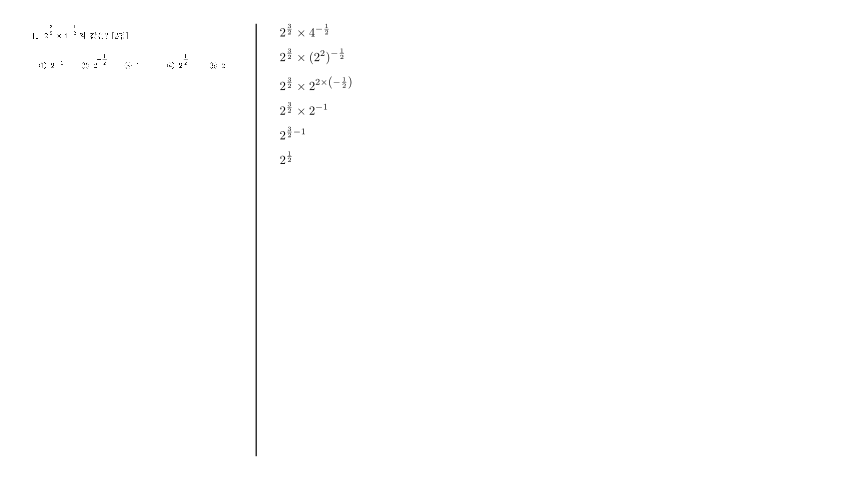

In [ ]:
%%manim -s -ql -v WARNING Problem7Solve
from study.pdf_tools import pdf_problem_image


def place_in_region(mobject, left, top, width):
    if mobject.width > width:
        mobject.scale_to_fit_width(width)
    mobject.move_to([left + mobject.width / 2, top - mobject.height / 2, 0])
    return mobject


class Problem7Solve(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE

        margin = 0.4
        content_width = config.frame_width - 2 * margin
        content_height = config.frame_height - 2 * margin
        content_left = -config.frame_width / 2 + margin
        content_right = config.frame_width / 2 - margin
        content_top = config.frame_height / 2 - margin
        
        boundary_x = config.frame_width * -0.2

        problem_width = boundary_x - content_left - margin
        problem_x = content_left
        
        solution_width = content_right - boundary_x - margin
        solution_x = boundary_x + margin

        divider = Line(
            start=[boundary_x, content_top, 0],
            end=[boundary_x, content_top - content_height, 0],
            color=BLACK,
            stroke_width=2,
        )
        
        problem_image = pdf_problem_image(
            "mathB_1_mun_ZM4M1F58.pdf",
            problem_number=1,
        )
        place_in_region(
            problem_image,
            problem_x,
            content_top,
            problem_width
        )

        solution = VGroup(
            MathTex(r"2^{\frac{3}{2}} \times 4^{-\frac{1}{2}}"),
            MathTex(r"2^{\frac{3}{2}} \times (2^2)^{-\frac{1}{2}}"),
            MathTex(r"2^{\frac{3}{2}} \times 2^{2 \times \left(-\frac{1}{2}\right)}"),
            MathTex(r"2^{\frac{3}{2}} \times 2^{-1}"),
            MathTex(r"2^{\frac{3}{2}-1}"),
            MathTex(r"2^{\frac{1}{2}}"),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.2)
        place_in_region(
            solution,
            solution_x,
            content_top,
            solution_width
        )
    
        self.add(divider, problem_image, solution)


In [ ]:
%%manim -ql -v WARNING TestScene
import importlib
import module.auto_math_steps

importlib.reload(module.auto_math_steps)
AutoMathSteps = module.auto_math_steps.AutoMathSteps

class TestScene(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE

        solution = AutoMathSteps(
            r"2^{\frac{3}{2}} \times 4^{-\frac{1}{2}}",
            r"= 2^{\frac{3}{2}} \times (2^2)^{-\frac{1}{2}}",
            r"= 2^{\frac{3}{2}} \times 2^{2 \times \left(-\frac{1}{2}\right)}",
            r"= 2^{\frac{3}{2}} \times 2^{-1}",
            r"= 2^{\frac{3}{2}-1}",
            r"= 2^{\frac{1}{2}}",
            color=BLACK,
            font_size=48,
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.2)

        # 전체 풀이가 화면 안에 들어오도록 배치
        solution.scale_to_fit_height(6).move_to(ORIGIN)

        solution.play(self, run_time=1.5)
        self.wait(1)

Manim Community v0.21.0

## 애니메이션 풀이와 정적 풀이를 연결한 최종 구성

In [ ]:
%%manim -ql -v WARNING Problem7Final
from study.pdf_tools import pdf_problem_image


def place_in_region_final(mobject, left, top, width):
    if mobject.width > width:
        mobject.scale_to_fit_width(width)
    mobject.move_to([left + mobject.width / 2, top - mobject.height / 2, 0])
    return mobject


class Problem7Final(MovingCameraScene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=20)

        margin = 0.4
        content_left = -config.frame_width / 2 + margin
        content_right = config.frame_width / 2 - margin
        content_top = config.frame_height / 2 - margin
        content_height = config.frame_height - 2 * margin

        boundary_x = config.frame_width * -0.1
        problem_width = boundary_x - content_left - margin
        solution_width = content_right - boundary_x - margin
        solution_x = boundary_x + margin

        divider = Line(
            start=[boundary_x, content_top, 0],
            end=[boundary_x, content_top - content_height, 0],
            color=BLACK,
            stroke_width=2,
        )
        problem_image = pdf_problem_image(
            "mathB_1_mun_ZM4M1F58.pdf",
            problem_number=1,
        )
        place_in_region_final(problem_image, content_left, content_top, problem_width)

        self.add(divider, problem_image)
        self.wait(1)

        self.camera.frame.save_state()
        self.play(
            self.camera.frame.animate.move_to(problem_image).scale(0.72),
            run_time=1.2,
        )
        self.wait(1)
        self.play(Restore(self.camera.frame), run_time=1.0)

        animated_solution = MathTex(
            Term(2, Fraction(3, 2)),
            r"\times",
            Term(4, MathTex("-", Fraction(1, 2))),
        )
        place_in_region_final(
            animated_solution,
            solution_x,
            content_top,
            solution_width,
        )
        self.add(animated_solution)
        self.play(
            self.camera.frame.animate.move_to(animated_solution).scale(0.58),
            run_time=1.2,
        )
        self.wait(0.7)

        animated_solution[2].base = ["(", Term(2, 2), ")"]
        self.play(TransformInStages.progress(animated_solution), run_time=1.0)

        term = animated_solution[2].base[1]
        animated_solution[2].base = term.base
        animated_solution[2].exponent = [
            term.exponent,
            r"\times",
            Paren(MathTex("-", Fraction(1, 2))),
        ]
        self.play(TransformInStages.progress(animated_solution), run_time=1.0)

        animated_solution[2].exponent = MathTex(-1)
        self.play(TransformInStages.progress(animated_solution), run_time=1.0)

        old_terms = animated_solution.terms
        animated_solution.terms = MathTex(
            Term(animated_solution[0].base, [
                animated_solution[0].exponent,
                animated_solution[2].exponent,
            ])
        )
        old_terms[0].base.merge(old_terms[2].base)
        self.play(TransformInStages.progress(animated_solution), run_time=1.0)

        animated_solution[0].exponent = MathTex(Fraction(1, 2))
        self.play(TransformInStages.progress(animated_solution), run_time=1.0)
        final_box = SurroundingRectangle(animated_solution, color=BLUE, buff=0.15)
        self.play(Create(final_box), run_time=0.5)
        self.wait(1)

        self.play(Restore(self.camera.frame), run_time=1.2)
        static_solution = VGroup(
            MathTex(r"2^{\frac{3}{2}} \times 4^{-\frac{1}{2}}"),
            MathTex(r"=2^{\frac{3}{2}} \times (2^2)^{-\frac{1}{2}}"),
            MathTex(r"=2^{\frac{3}{2}} \times 2^{2 \times \left(-\frac{1}{2}\right)}"),
            MathTex(r"=2^{\frac{3}{2}} \times 2^{-1}"),
            MathTex(r"=2^{\frac{3}{2}-1}"),
            MathTex(r"=2^{\frac{1}{2}}"),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.16)
        place_in_region_final(static_solution, solution_x, content_top, solution_width)

        self.play(
            FadeOut(animated_solution, final_box),
            FadeIn(static_solution),
            run_time=1.2,
        )
        self.wait(2)

Manim Community v0.21.0

## reactive_manim 전체 기능 예제

아래 셀들은 `reactive_manim`의 공개 사용 기능을 작은 장면별로 나눈 예제입니다. 먼저 공통 설정 셀을 실행한 뒤, 보고 싶은 장면의 `%%manim` 셀을 개별 실행하세요.

In [ ]:
%%manim -ql -v WARNING ReactiveBasics
class ReactiveBasics(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=54)

        base = MathTex("x")
        exponent = MathTex(2, color=BLUE)
        expression = MathTex(Term(base, exponent), r"+", MathTex("1"))
        expression.move_to(ORIGIN)
        self.add(expression)
        self.wait(0.5)

        # 자식 프로퍼티 변경은 기존 렌더링 구조를 유지하며 갱신됩니다.
        expression[0].base = MathTex("y", color=RED)
        expression[0].exponent = MathTex(3, color=GREEN)
        self.play(TransformInStages.progress(expression))
        self.wait(0.5)

        expression[2] = MathTex("4")
        self.play(TransformInStages.progress(expression))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING ReactiveComponents
class ReactiveComponents(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=38)

        examples = VGroup(
            MathTex(Term("x", 2)),
            MathTex(Fraction(1, 2)),
            MathTex(Function("f", "x")),
            MathTex(Parentheses(MathTex("a+b"))),
            MathTex(Root("x+1")),
            MathTex(MathList("a", "b", "c")),
            MathTex(MathSequence("u", "v", "w")),
        ).arrange(DOWN, aligned_edge=LEFT, buff=0.28)
        examples.scale_to_fit_height(6.5)
        self.add(examples)
        self.wait(2)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING ReactiveCollections
class ReactiveCollections(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=48)

        sequence = MathTex("x", "=", "1")
        self.add(sequence)
        self.wait(0.4)

        sequence.insert(0, MathTex("f(x)"))
        sequence.insert(1, MathTex("+"))
        sequence.append(MathTex(r"\quad (x>0)"))
        self.play(TransformInStages.progress(sequence))
        self.wait(0.5)

        sequence.remove(sequence[1])
        self.play(TransformInStages.progress(sequence))
        self.wait(0.5)

        equation = MathTex("x", "=", "1").move_to(DOWN * 1.5)
        self.add(equation)
        equation.LHS = MathTex(r"f(x)")
        equation.RHS = MathTex(r"x^2+1")
        self.play(TransformInStages.progress(equation))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING ReactiveCasesAndMatrix
class ReactiveCasesAndMatrix(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=40)

        cases = MathTex(MathCases(
            CaseLine("x^2", r"x\geq 0"),
            CaseLine("-x", r"x<0"),
        ))
        matrix = MathTex(MathMatrix([[1, 2], [3, 4]]))
        manim_matrix = MathTex(ManimMatrix([["a", "b"], ["c", "d"]]))
        group = VGroup(cases, matrix, manim_matrix).arrange(DOWN, buff=0.55)
        self.add(group)
        self.wait(0.5)

        cases[0].append(CaseLine("0", r"x=0"))
        matrix[0].matrix = [[1, 9], [3, 4]]
        manim_matrix[0].matrix = [["a", "b"], ["z", "d"]]
        self.play(
            TransformInStages.progress(cases),
            TransformInStages.progress(matrix),
            TransformInStages.progress(manim_matrix),
        )
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING ReactiveTransformModes
class ReactiveTransformModes(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=52)

        progress = MathTex("x", "^", "2")
        progress.move_to(UP * 2)
        self.add(progress)
        progress[0] = MathTex("y")
        self.play(TransformInStages.progress(progress))

        source = MathTex(r"a+b").move_to(ORIGIN)
        target = MathTex(r"a-b").move_to(ORIGIN)
        self.play(TransformInStages.replacement_transform(source, target))

        copied_source = MathTex(r"u+v").move_to(DOWN * 2)
        copied_target = MathTex(r"u-v").move_to(DOWN * 2)
        self.add(copied_source)
        self.play(TransformInStages.from_copy(copied_source, copied_target))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING ReactiveDGroup
class ReactiveDGroup(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=48)

        left = MathTex("x", color=BLUE)
        right = MathTex("+1", color=GREEN)
        group = DGroup(left, right).arrange(RIGHT, buff=0.35)
        self.add(group)
        self.wait(0.5)

        # DGroup의 자식 추가/삭제도 그래프에 반영됩니다.
        group.add(MathTex("=2", color=RED))
        group.arrange(RIGHT, buff=0.35)
        self.play(TransformInStages.progress(group))
        self.wait(0.5)

        group.remove(right)
        group.arrange(RIGHT, buff=0.35)
        self.play(TransformInStages.progress(group))
        self.wait(1)

Manim Community v0.21.0

In [ ]:
%%manim -ql -v WARNING ReactivePropertyEdits
class ReactivePropertyEdits(Scene):
    def construct(self):
        self.camera.background_color = WHITE
        MathTex.set_default(color=BLACK, font_size=48)

        fraction = Fraction(1, 2)
        function = Function("f", "x")
        parentheses = Parentheses(MathTex("a+b"))
        label = MathString("initial")
        display = VGroup(
            MathTex(fraction),
            MathTex(function),
            MathTex(parentheses),
            MathTex(label),
        ).arrange(DOWN, buff=0.35)
        self.add(display)
        self.wait(0.5)

        fraction.numerator = MathTex("x+1")
        fraction.denominator = MathTex("x-1")
        function.function_name = "g"
        function.input = MathTex("t")
        parentheses.inner = MathTex("u-v")
        label.set_tex_string("updated")
        self.play(
            TransformInStages.progress(display[0]),
            TransformInStages.progress(display[1]),
            TransformInStages.progress(display[2]),
            TransformInStages.progress(display[3]),
        )
        self.wait(1)

Manim Community v0.21.0